In [1]:
# pip install cdsapi xarray netCDF4 numpy pandas matplotlib scipy metpy


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Download ERA5 hourly data

In [ ]:
#Download thermodynamic variables for the event period
import cdsapi

    # "variable": [
    #     "temperature",
    #     "specific_humidity",
    #     "geopotential",
    #     "vertical_velocity"
    # ]

dataset = "reanalysis-era5-pressure-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["vertical_velocity"],
    "year": ["2025"],
    "month": ["05"],
    "day": [
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "pressure_level": [
        "100", "200", "300",
        "400", "450", "500",
        "550", "600", "650",
        "700", "750", "800",
        "850", "900", "925",
        "950", "975", "1000"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [14, 76, 12, 78]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-04-17 02:09:47,438 INFO Request ID is c8a1fecd-4fa3-42ec-9c82-4cb78cd9422f
2026-04-17 02:09:47,553 INFO status has been updated to accepted
2026-04-17 02:10:01,325 INFO status has been updated to running
2026-04-17 02:24:11,679 INFO status has been updated to successful


'9cb35efa69db3eb08fba3ea6b8c71fc5.nc'

In [ ]:
#Download precipitation data for the event period
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["total_precipitation"],
    "year": ["2025"],
    "month": ["05"],
    "day": [
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [14, 76, 12, 78]
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-04-17 12:10:22,022 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-17 12:10:22,028 INFO Request ID is 4253f21a-89c4-42a3-97f2-a3d15e151fa0
2026-04-17 12:10:22,142 INFO status has been updated to accepted
2026-04-17 12:10:36,198 INFO status has been updated to running
2026-04-17 12:11:13,257 INFO status has been updated to successful


'4be8d80c8078766dd92c340601c9af7.nc'

# Visualize data

import libraries

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from metpy.calc import virtual_potential_temperature
from metpy.units import units

/Users/bidyut/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load files

In [ ]:
#Load datasets
ds_geopotential = xr.open_dataset("Blore_19May2025_event_geopotential.nc")
ds_vertical_velocity = xr.open_dataset("Blore_19May2025_event_vertical_velocity.nc")
ds_temperature = xr.open_dataset("Blore_19May2025_event_temperature.nc")
ds_specific_humidity = xr.open_dataset("Blore_19May2025_event_specific_humidity.nc")
ds_total_precipitation = xr.open_dataset("Blore_19May2025_event_total_precipitation.nc")


# Area mean
ds_geopotential_mean = ds_geopotential.mean(dim=["latitude", "longitude"])
ds_vertical_velocity_mean = ds_vertical_velocity.mean(dim=["latitude", "longitude"])
ds_temperature_mean = ds_temperature.mean(dim=["latitude", "longitude"])
ds_specific_humidity_mean = ds_specific_humidity.mean(dim=["latitude", "longitude"])
ds_total_precipitation_mean = ds_total_precipitation.mean(dim=["latitude", "longitude"])

compute thermodynamic fields

In [90]:
#Compute virtual potential temperature

T = ds_temperature_mean["t"] * units.kelvin
q = ds_specific_humidity_mean["q"] * units.dimensionless

print(T.metpy.units)  # kelvin
print(q.metpy.units)  # dimensionless

p = ds_temperature_mean["pressure_level"].values * units.hPa
p_da = xr.DataArray(
    p,
    dims=("pressure_level",),
    coords={"pressure_level": ds_temperature_mean["pressure_level"]}
)

p_2d = xr.broadcast(T, p_da)[1]


# print(p_2d)
# print(T)
# print(q)

theta_v = virtual_potential_temperature(p_2d, T, q)

# print(theta_v)
print(theta_v.dims)
print(theta_v.shape)

kelvin
dimensionless
('valid_time', 'pressure_level')
(360, 18)


In [146]:
#Compute height from geopotential

g = 9.81
z = ds_geopotential_mean["z"]/ g
print(z.values) # it is in meters

[[   91.668      308.57733    531.16016  ...  9702.526    12469.312
  16618.836   ]
 [   97.20829    314.03476    536.5289   ...  9709.805    12475.279
  16625.633   ]
 [  104.65351    321.5934     544.22046  ...  9719.3955   12483.878
  16634.672   ]
 ...
 [   42.56573    259.77664    482.65042  ...  9716.272    12501.989
  16675.285   ]
 [   42.802505   259.97964    482.82065  ...  9711.856    12499.615
  16670.822   ]
 [   43.984764   261.10202    483.88138  ...  9712.073    12498.811
  16670.875   ]]


In [92]:
#Compute vertical derivative dtheta_v/dz = dtheta_v/dp * dz/dp
dtheta_dp = theta_v.differentiate("pressure_level")
dz_dp = z.differentiate("pressure_level")

# chain rule
dtheta_dz = dtheta_dp / dz_dp 

In [93]:
# Compute N²
N2 = (g / theta_v) * dtheta_dz
N2 = N2.rename("N2")
print(N2.metpy.units)

dimensionless


This is due to stripping of units while differentiating using xarray.differentiate() 

### Physical Units Consistency Check

- Virtual potential temperature, \( \theta_v \):  
  **Units:** K

- Vertical gradient of virtual potential temperature, \( \partial \theta_v / \partial z \):  
  **Units:** K m⁻¹

- Gravitational term, \( g / \theta_v \):  
  **Units:** m s⁻² K⁻¹

- Brunt–Väisälä frequency squared, \( N^2 \):  
  **Units:** s⁻²

In [94]:

# Re-attach correct physical units

from metpy.units import units

N2 = N2 * units("s^-2")
print(N2.metpy.units)


1 / second ** 2


In [95]:
#Sanity check of N2 values
print(N2.min().values, N2.max().values)

-1.0099788245345314e-05 0.00023102597050808507


Plot

In [108]:
#Variables needed to plot
# Time–height contour of N²
# Rainfall time series (overlay)
# Boundary‑layer stability shading
# Visual cues for pre‑event destabilization and post‑event stabilization
    
#N2        # DataArray (valid_time, pressure_level), units s^-2
#z         # DataArray (valid_time, pressure_level), meters
rain = ds_total_precipitation_mean["tp"]*1000     # DataArray (valid_time), mm/hour or mm

In [98]:
len(rain)

360

In [99]:
#convert vertical coordinates to height in km
height_km = (z.mean("valid_time") / 1000).rename("height_km")

In [151]:
#Prepare N² time–height matrix
N2_plot = N2.transpose("pressure_level", "valid_time")
N2_plot = N2_plot * 1e4  # scale for better visualization


In [154]:
#Define plotting limits and levels
max=N2_plot.max().values
levels = np.linspace(-max, max, 21)

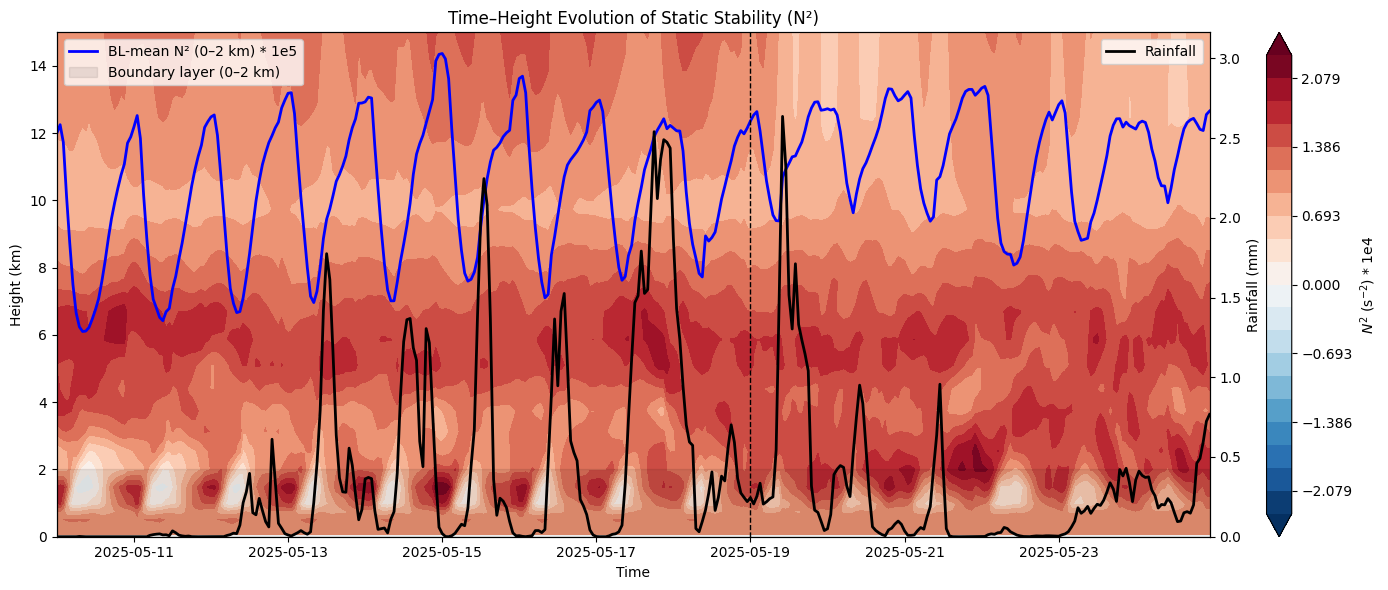

In [156]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# ---- 1. Time–height contour of N² ----
cf = ax.contourf(
    N2_plot["valid_time"],
    height_km,
    N2_plot,
    levels=levels,
    cmap="RdBu_r",
    extend="both"
)

# plot N² at averaged over BL height (0–2 km) as a black line

#Create a height mask (0–2 km)
bl_mask = (height_km >= 0) & (height_km <= 2)
# Apply mask to N²
N2_masked = N2.where(bl_mask)
# Vertically average over the BL
N2_bl = N2_masked.mean(dim="pressure_level")
# Scale for visibility
N2_bl_plot = N2_bl * 1e5

ax.plot(
    N2_bl_plot["valid_time"],
    N2_bl_plot,
    color="blue",
    linewidth=2,
    label="BL-mean N² (0–2 km) * 1e5"
)


#push the colorbar right and away from the plot

cbar = plt.colorbar(cf, ax=ax, pad=0.04)
cbar.set_label(r"$N^2$ (s$^{-2}$) * 1e4")

ax.set_ylabel("Height (km)")
ax.set_xlabel("Time")
ax.set_ylim(0, 15)
ax.set_title("Time–Height Evolution of Static Stability (N²)")

# ---- 2. Boundary‑layer mixing (diagnostic shading) ----
ax.axhspan(0, 2, color="k", alpha=0.08, label="Boundary layer (0–2 km)")

# ---- 3. Rainfall overlay ----
ax2 = ax.twinx()
ax2.plot(
    rain["valid_time"],
    rain,
    color="black",
    linewidth=2,
    label="Rainfall"
)
ax2.set_ylabel("Rainfall (mm)")
ax2.set_ylim(0, rain.max() * 1.2)

# ---- 4. Event reference line ----
event_time = np.datetime64("2025-05-19")  # example
ax.axvline(event_time, color="k", linestyle="--", linewidth=1)

# Legends
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

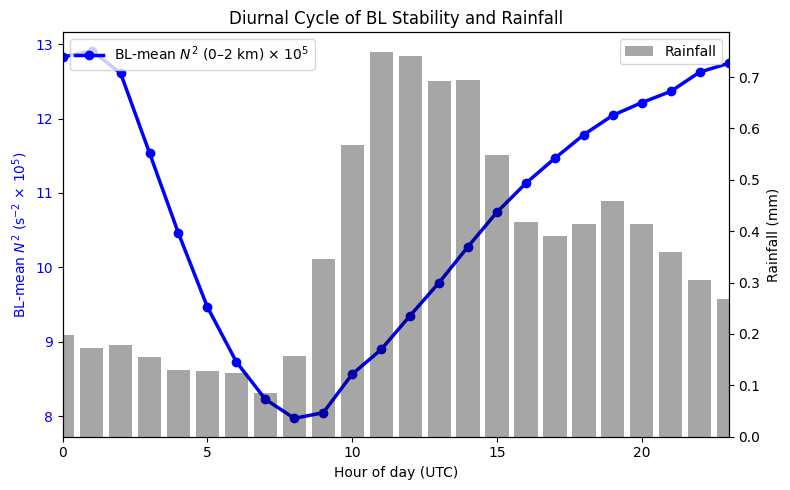

In [159]:
#plot N2_bl and rain diurnal cycle climatology together

hour = N2_bl["valid_time"].dt.hour

N2_bl_diurnal = (N2_bl * 1e5).groupby("valid_time.hour").mean()
rain_diurnal = rain.groupby("valid_time.hour").mean()


fig, ax1 = plt.subplots(figsize=(8, 5))

# ---- BL-mean N² diurnal cycle ----
ax1.plot(
    N2_bl_diurnal["hour"],
    N2_bl_diurnal,
    color="blue",
    linewidth=2.5,
    marker="o",
    label=r"BL-mean $N^2$ (0–2 km) × 10$^5$"
)

ax1.set_xlabel("Hour of day (UTC)")
ax1.set_ylabel(r"BL-mean $N^2$ (s$^{-2}$ × 10$^5$)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_xlim(0, 23)

# ---- Rainfall diurnal cycle ----
ax2 = ax1.twinx()
ax2.bar(
    rain_diurnal["hour"],
    rain_diurnal,
    color="black",
    alpha=0.35,
    width=0.8,
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# ---- Title & legend ----
ax1.set_title("Diurnal Cycle of BL Stability and Rainfall")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

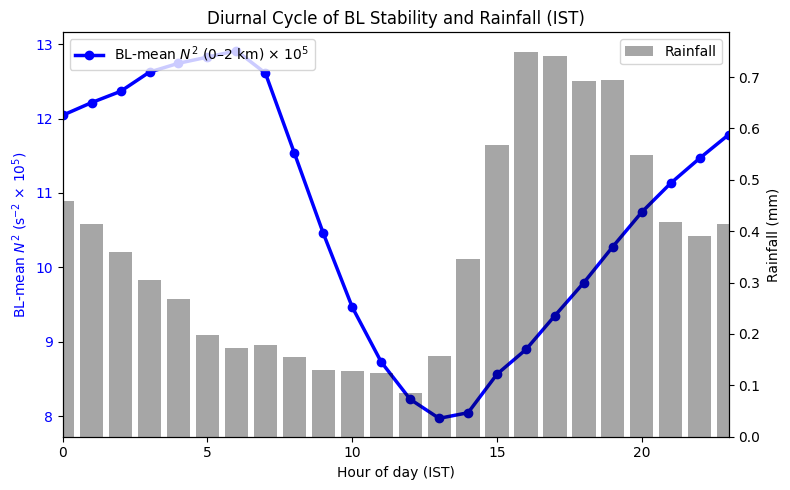

In [160]:
import numpy as np

# Shift time to local IST (UTC + 5h30m)
N2_bl_ist = N2_bl.assign_coords(
    valid_time=N2_bl.valid_time + np.timedelta64(330, "m")
)

rain_ist = rain.assign_coords(
    valid_time=rain.valid_time + np.timedelta64(330, "m")
)
# Re-plot diurnal cycle in IST
N2_bl_diurnal_ist = (N2_bl_ist * 1e5).groupby("valid_time.hour").mean()
rain_diurnal_ist = rain_ist.groupby("valid_time.hour").mean()

#Plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

# ---- BL-mean N² diurnal cycle ----
ax1.plot(
    N2_bl_diurnal_ist["hour"],
    N2_bl_diurnal_ist,
    color="blue",
    linewidth=2.5,
    marker="o",
    label=r"BL-mean $N^2$ (0–2 km) × 10$^5$"
)

ax1.set_xlabel("Hour of day (IST)")
ax1.set_ylabel(r"BL-mean $N^2$ (s$^{-2}$ × 10$^5$)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_xlim(0, 23)

# ---- Rainfall diurnal cycle ----
ax2 = ax1.twinx()
ax2.bar(
    rain_diurnal_ist["hour"],
    rain_diurnal_ist,
    color="black",
    alpha=0.35,
    width=0.8,
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# Legends and title
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax1.set_title("Diurnal Cycle of BL Stability and Rainfall (IST)")

plt.tight_layout()
plt.show()


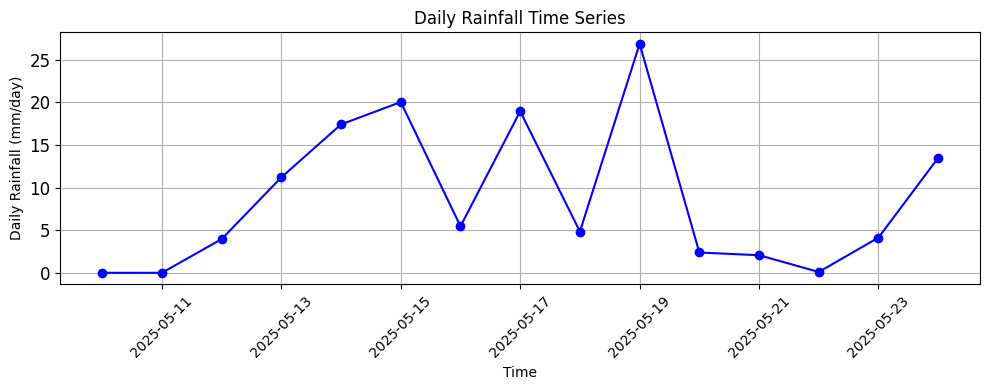

In [139]:
#Plot rainfall time series as daily rainfall (mm/day)
point_rain=ds_total_precipitation.sel(longitude=76.25, latitude=13.25, method="nearest")["tp"]*1000   # mm/hour or mm
daily_rain = point_rain.resample(valid_time="1D").sum()
plt.figure(figsize=(10, 4))
plt.plot(daily_rain["valid_time"], daily_rain, marker="o", color="blue")
plt.xticks(rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Time")
plt.ylabel("Daily Rainfall (mm/day)")
plt.title("Daily Rainfall Time Series")
plt.grid(True)
plt.tight_layout()
plt.show()

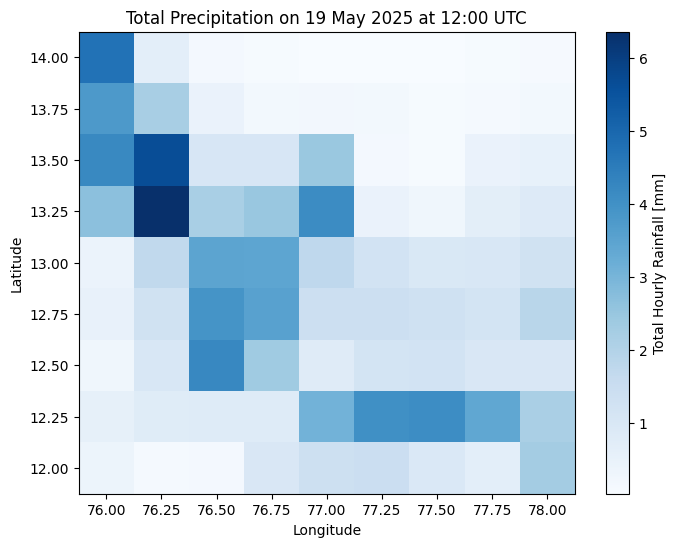

In [144]:
#plot map of ds_total_precipitation on 19 May 2025
precip_19may = ds_total_precipitation.sel(valid_time="2025-05-19T12:00:00")
#convert from m to mm by multiplying by 1000 and assigning correct units
precip_19may["tp"] = precip_19may["tp"] * 1000
precip_19may["tp"].attrs["units"] = "mm"
precip_19may["tp"].attrs["long_name"] = "Total Hourly Rainfall"

plt.figure(figsize=(8, 6))
precip_19may["tp"].plot(cmap="Blues")
plt.title("Total Precipitation on 19 May 2025 at 12:00 UTC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
